# Relocation Recommender — Exploratory Data Analysis

Notebook covers:
1. Dataset overview & descriptive statistics
2. Correlation heatmap
3. Top-10 countries per key index
4. Scatter: cost of living vs safety index
5. Scatter: GDP per capita vs healthcare index

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── paths ─────────────────────────────────────────────────────────────────
DATA_PATH    = Path('..') / 'data' / 'processed' / 'countries.csv'
FIGURES_DIR  = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

# ── style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'savefig.bbox': 'tight'})

print('Figures will be saved to:', FIGURES_DIR.resolve())

Figures will be saved to: C:\Users\user\relocation_recommender\notebooks\figures


---
## 1. Dataset Overview

In [2]:
df = pd.read_csv(DATA_PATH, index_col='iso3')

print(f'Shape : {df.shape[0]} countries × {df.shape[1]} columns')
print(f'Missing values : {df.isna().sum().sum()}')
print()
print('Columns:')
for col in df.columns:
    print(f'  {col:<35} dtype={df[col].dtype}')

Shape : 87 countries × 21 columns
Missing values : 0

Columns:
  gdp_per_capita                      dtype=float64
  unemployment_rate                   dtype=float64
  life_expectancy                     dtype=float64
  literacy_rate                       dtype=float64
  gini_index                          dtype=float64
  cost_of_living_index                dtype=float64
  rent_index                          dtype=float64
  groceries_index                     dtype=float64
  restaurant_price_index              dtype=float64
  purchasing_power_index              dtype=float64
  safety_index                        dtype=float64
  healthcare_index                    dtype=float64
  traffic_index                       dtype=float64
  pollution_index                     dtype=float64
  visa_free_count                     dtype=float64
  residency_difficulty                dtype=float64
  digital_nomad_visa                  dtype=float64
  investor_visa                       dtype=float64
 

In [3]:
df.describe().round(3)

,gdp_per_capita,unemployment_rate,life_expectancy,literacy_rate,gini_index,cost_of_living_index,rent_index,groceries_index,restaurant_price_index,purchasing_power_index,safety_index,healthcare_index,traffic_index,pollution_index,visa_free_count,residency_difficulty,digital_nomad_visa,investor_visa,eu_member,schengen
count,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000,87.000
mean,0.215,0.183,0.794,0.820,0.902,0.324,0.320,0.339,0.330,0.442,0.596,0.526,0.331,0.533,0.786,0.464,0.621,0.667,0.356,0.368
std,0.209,0.132,0.167,0.145,0.247,0.202,0.212,0.200,0.228,0.241,0.213,0.210,0.199,0.266,0.268,0.271,0.488,0.474,0.482,0.485
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.053,0.102,0.721,0.833,0.965,0.161,0.153,0.185,0.140,0.236,0.478,0.385,0.187,0.308,0.708,0.333,0.000,0.000,0.000,0.000
50%,0.162,0.153,0.794,0.833,0.965,0.293,0.284,0.297,0.293,0.417,0.589,0.534,0.313,0.586,0.949,0.333,1.000,1.000,0.000,0.000
75%,0.321,0.217,0.924,0.834,0.965,0.457,0.451,0.497,0.468,0.654,0.758,0.683,0.433,0.757,0.964,0.667,1.000,1.000,1.000,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [4]:
# Missing-value heatmap (quick overview)
missing = df.isna().sum()
if missing.sum() > 0:
    missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 3))
    missing_pct[missing_pct > 0].plot.bar(ax=ax, color='salmon')
    ax.set_title('Missing values per column (%)')
    ax.set_ylabel('%')
    fig.savefig(FIGURES_DIR / '00_missing_values.png')
    plt.show()
else:
    print('No missing values — dataset is fully imputed.')

No missing values — dataset is fully imputed.


---
## 2. Correlation Heatmap

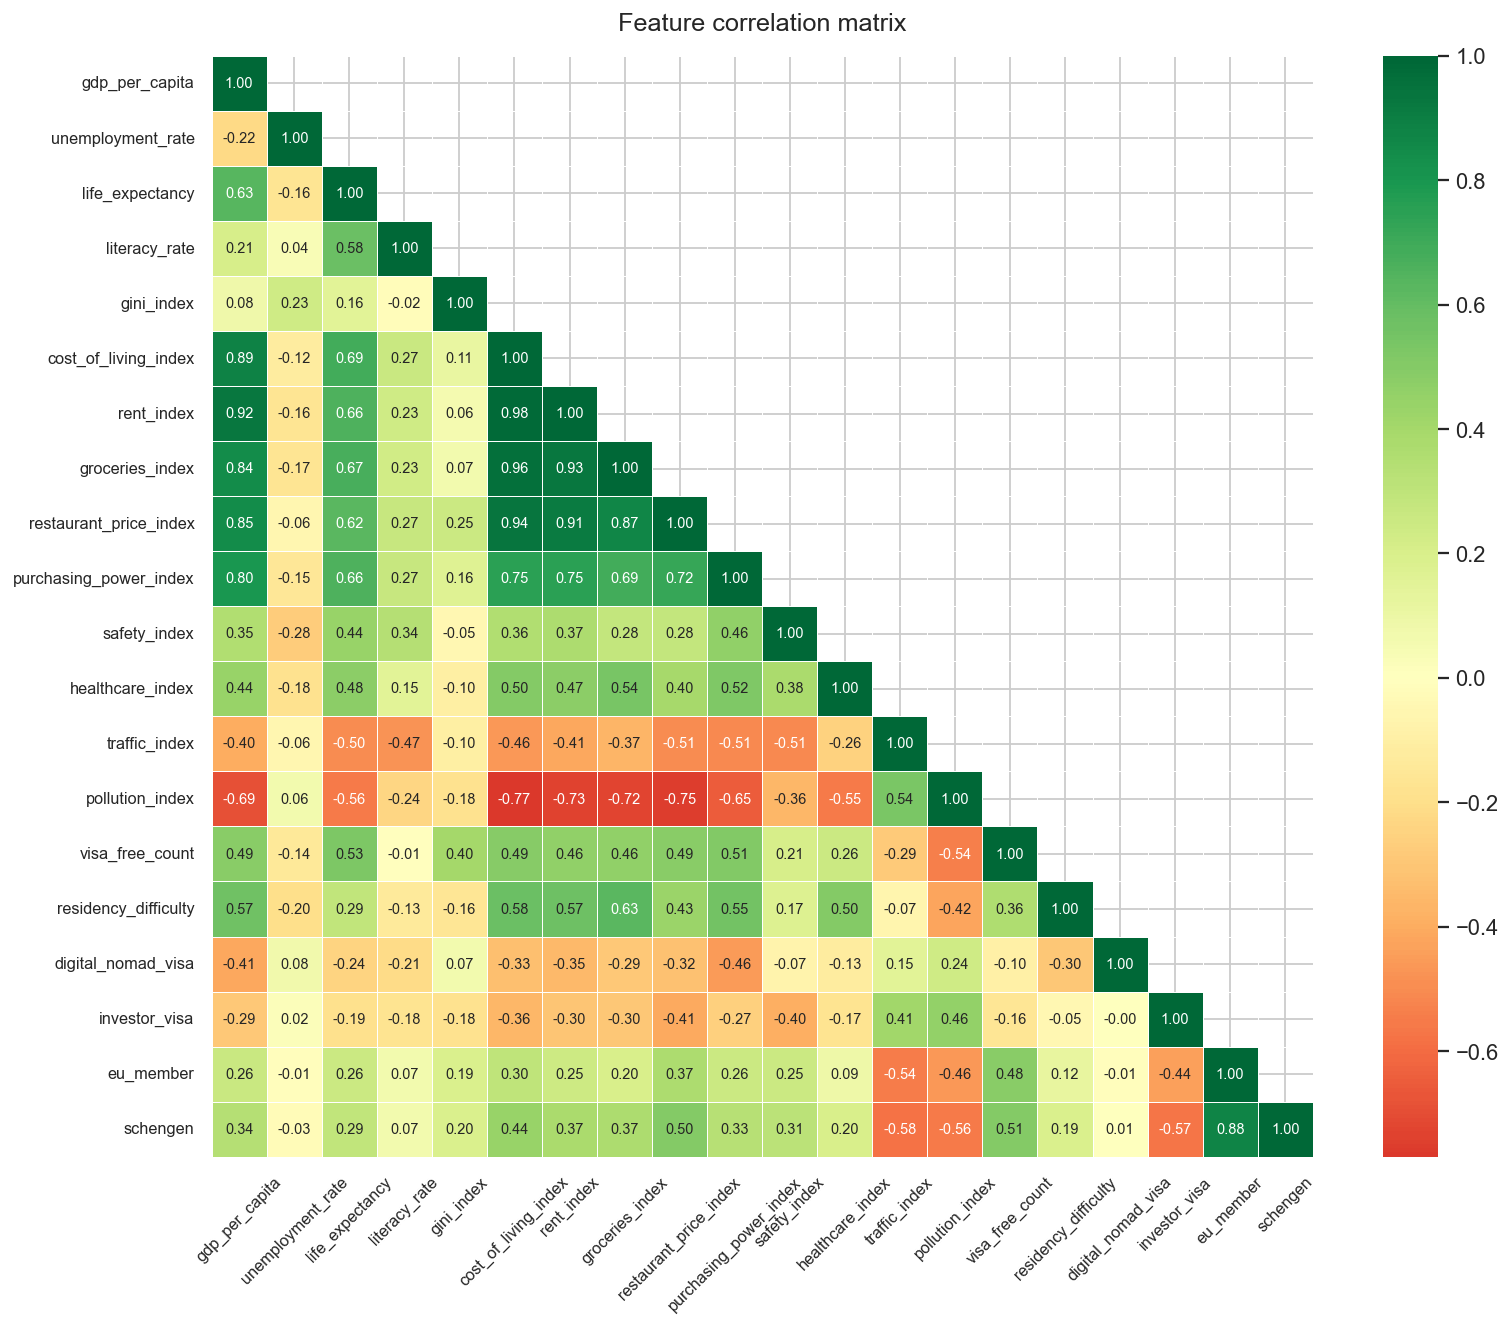

Saved → figures/01_correlation_heatmap.png


In [5]:
# Use only numeric feature columns (drop 'country' label if present)
num_df = df.select_dtypes(include='number')

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # show lower triangle only

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 8},
    square=True,
    ax=ax,
)

ax.set_title('Feature correlation matrix', fontsize=14, pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

fig.savefig(FIGURES_DIR / '01_correlation_heatmap.png')
plt.show()
print('Saved → figures/01_correlation_heatmap.png')

---
## 3. Top-10 Countries per Key Index

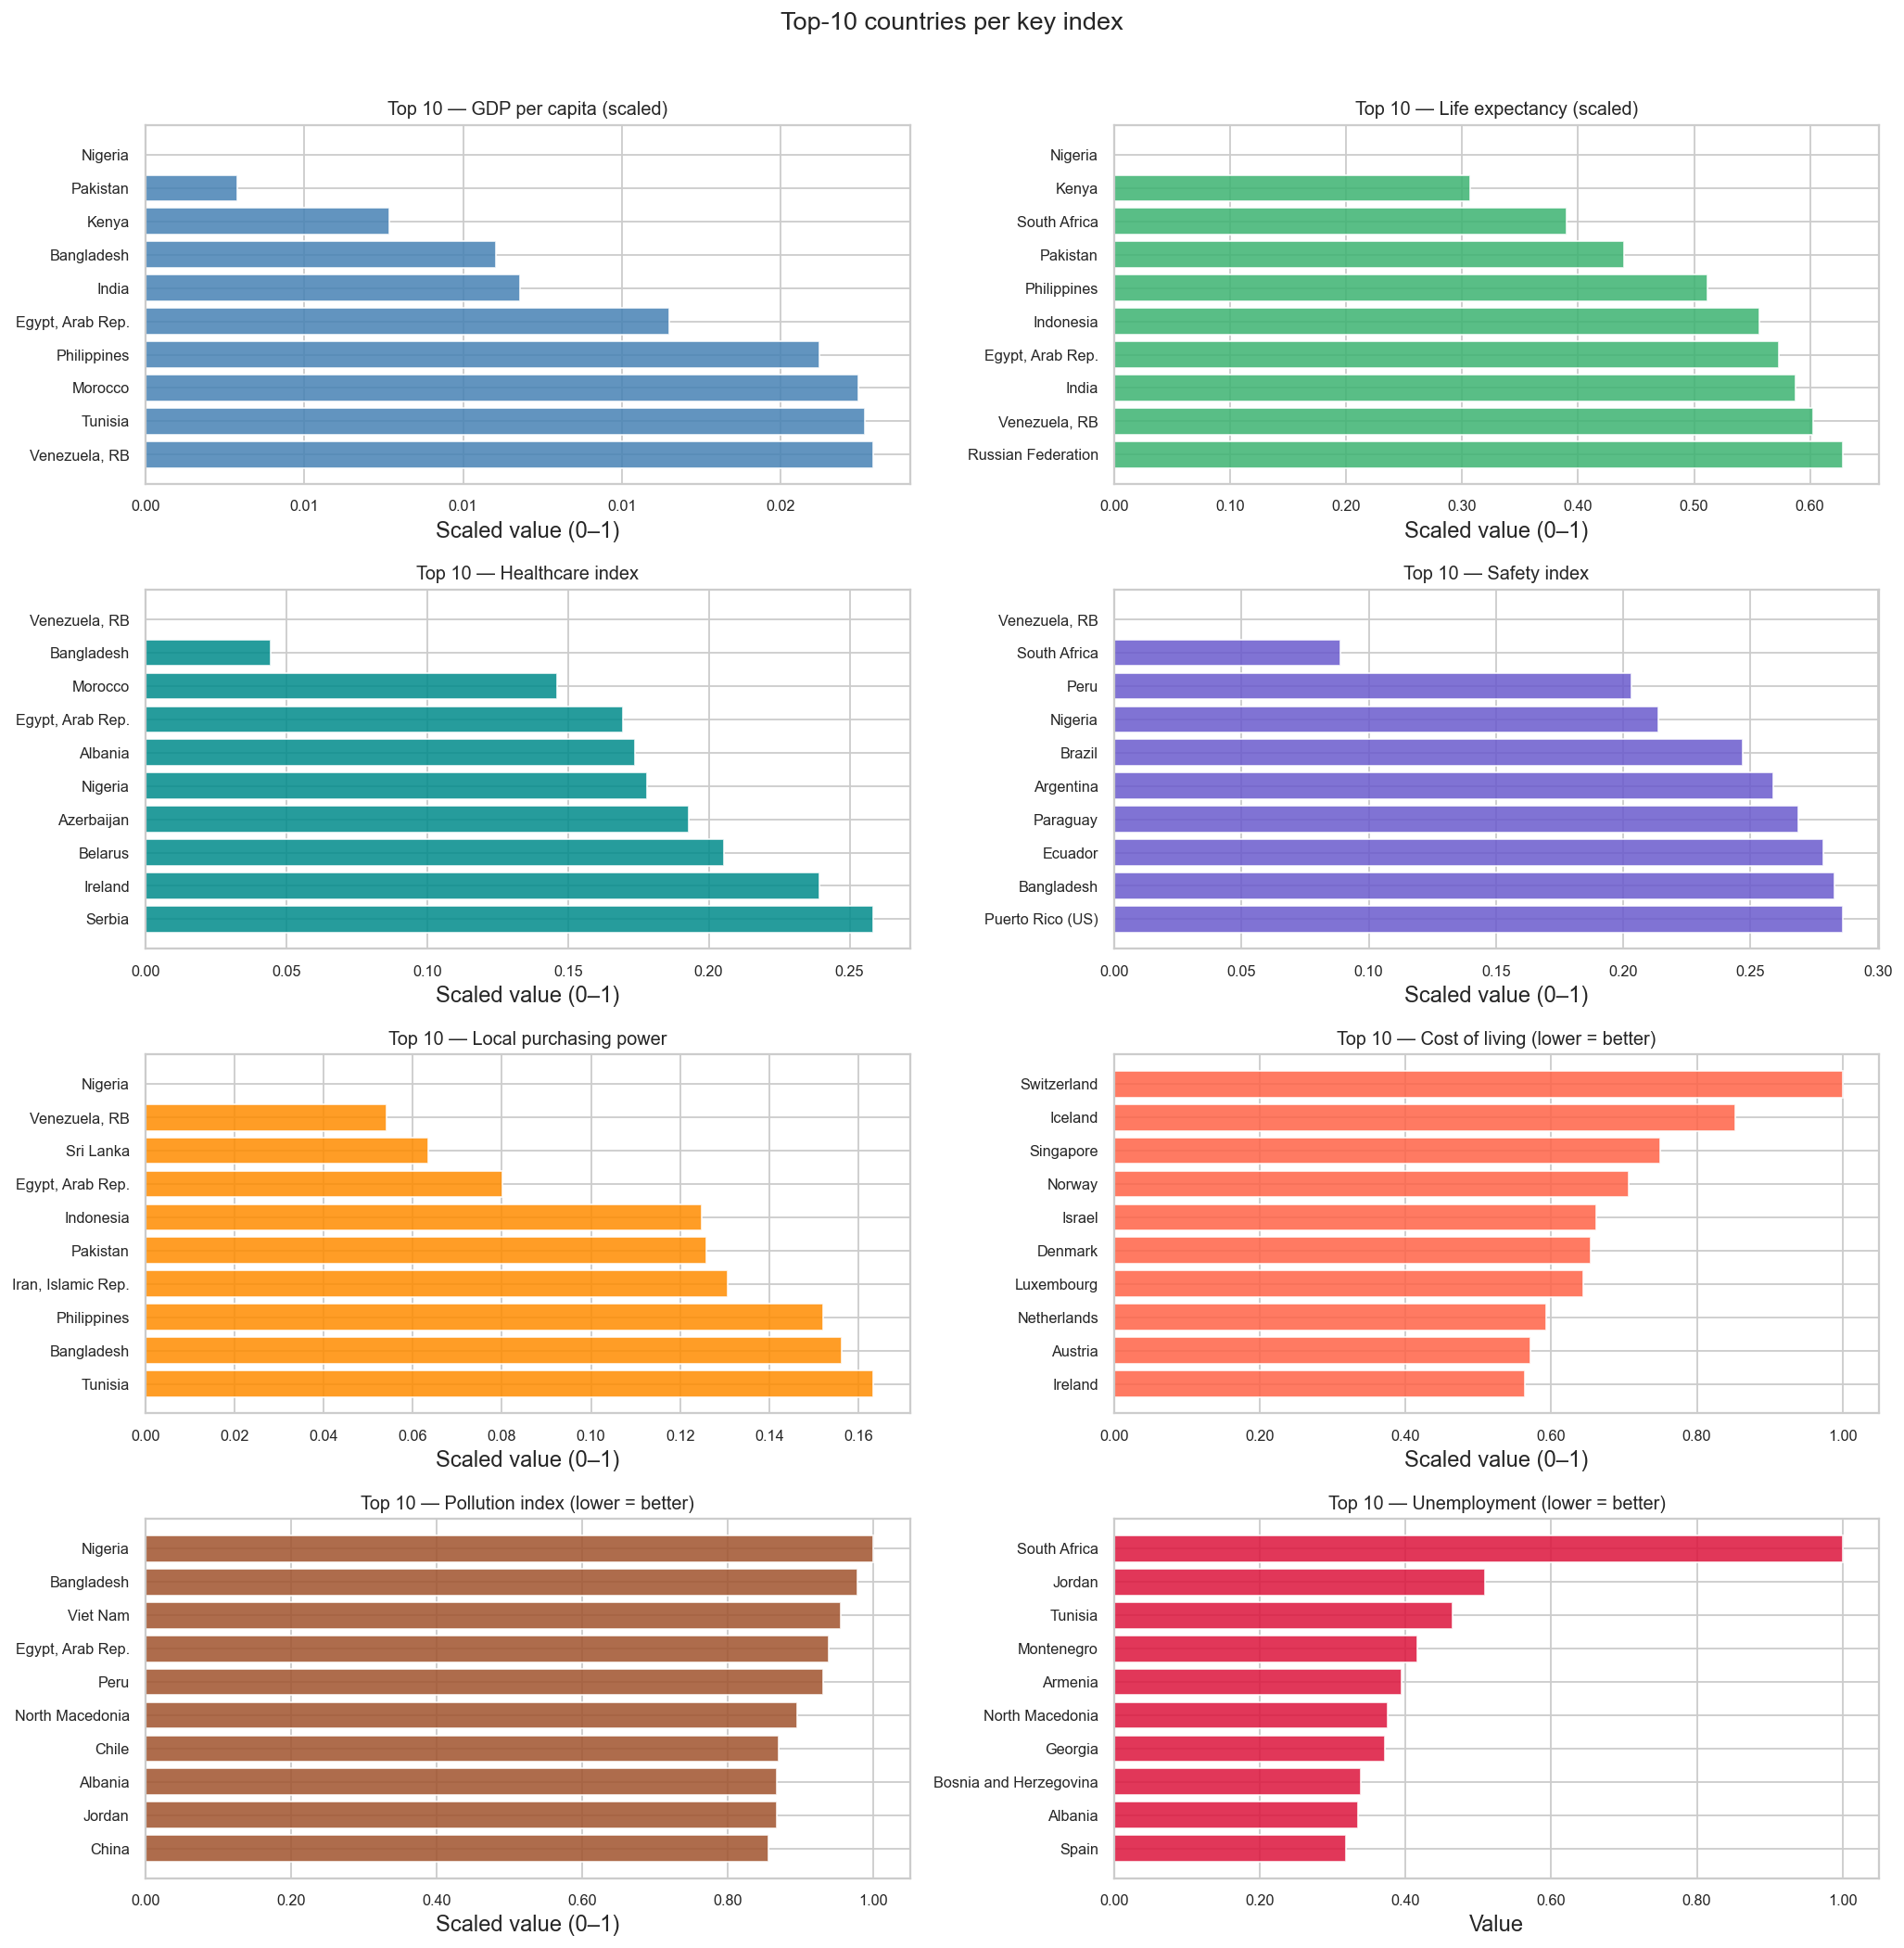

Saved → figures/02_top10_per_index.png


In [6]:
KEY_INDICES = {
    'gdp_per_capita':          ('GDP per capita (scaled)',      'steelblue',   True),
    'life_expectancy':         ('Life expectancy (scaled)',     'mediumseagreen', True),
    'healthcare_index':        ('Healthcare index',             'darkcyan',    True),
    'safety_index':            ('Safety index',                 'slateblue',   True),
    'purchasing_power_index':  ('Local purchasing power',       'darkorange',  True),
    'cost_of_living_index':    ('Cost of living (lower = better)', 'tomato',   False),
    'pollution_index':         ('Pollution index (lower = better)', 'sienna',  False),
    'unemployment_rate':       ('Unemployment (lower = better)', 'crimson',    False),
}

# Only keep indices that exist in this dataset
KEY_INDICES = {k: v for k, v in KEY_INDICES.items() if k in df.columns}

n_plots = len(KEY_INDICES)
ncols   = 2
nrows   = (n_plots + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

label_col = 'country' if 'country' in df.columns else df.index.name
labels    = df['country'] if 'country' in df.columns else df.index

for ax, (col, (title, color, higher_better)) in zip(axes, KEY_INDICES.items()):
    ascending = not higher_better   # sort ascending → worst first if lower-is-better
    top10 = (
        df[[col]]
        .assign(label=labels)
        .dropna(subset=[col])
        .sort_values(col, ascending=ascending)
        .tail(10)            # tail gives top-10 after ascending sort
    )
    ax.barh(top10['label'], top10[col], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top 10 — {title}', fontsize=11)
    ax.set_xlabel('Scaled value (0–1)' if top10[col].max() <= 1.0 else 'Value')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(labelsize=9)

# Hide unused subplot axes
for ax in axes[n_plots:]:
    ax.set_visible(False)

fig.suptitle('Top-10 countries per key index', fontsize=15, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_top10_per_index.png')
plt.show()
print('Saved → figures/02_top10_per_index.png')

---
## 4. Scatter: Cost of Living vs Safety Index

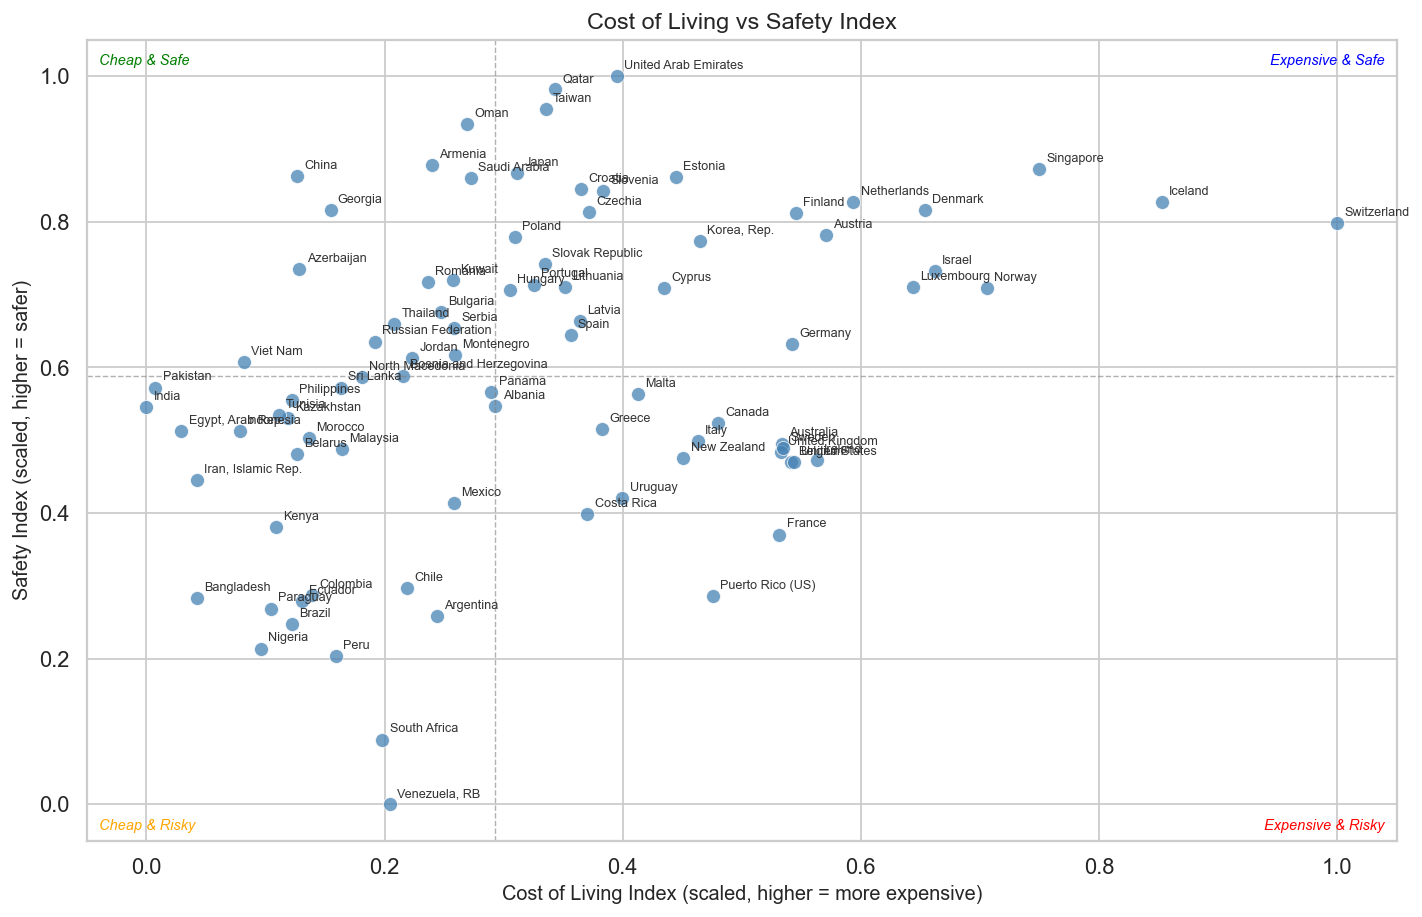

Saved → figures/03_cost_vs_safety.png


In [7]:
X_COL = 'cost_of_living_index'
Y_COL = 'safety_index'

missing = [c for c in (X_COL, Y_COL) if c not in df.columns]
if missing:
    print(f'Columns not found in dataset: {missing}. Skipping plot.')
else:
    plot_df = (
        df[[X_COL, Y_COL]]
        .assign(label=labels)
        .dropna(subset=[X_COL, Y_COL])
    )

    fig, ax = plt.subplots(figsize=(13, 8))

    ax.scatter(
        plot_df[X_COL], plot_df[Y_COL],
        s=60, alpha=0.75, color='steelblue', edgecolors='white', linewidths=0.5,
    )

    # Annotate every point
    for _, row in plot_df.iterrows():
        ax.annotate(
            row['label'],
            xy=(row[X_COL], row[Y_COL]),
            xytext=(4, 4), textcoords='offset points',
            fontsize=7, color='#333333',
        )

    # Quadrant lines at medians
    mx, my = plot_df[X_COL].median(), plot_df[Y_COL].median()
    ax.axvline(mx, color='grey', lw=0.8, ls='--', alpha=0.6)
    ax.axhline(my, color='grey', lw=0.8, ls='--', alpha=0.6)

    # Quadrant labels
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    ax.text(x_min + 0.01, y_max - 0.02, 'Cheap & Safe',    ha='left',  va='top', fontsize=8, color='green',  style='italic')
    ax.text(x_max - 0.01, y_max - 0.02, 'Expensive & Safe',ha='right', va='top', fontsize=8, color='blue',   style='italic')
    ax.text(x_min + 0.01, y_min + 0.01, 'Cheap & Risky',   ha='left',  va='bottom', fontsize=8, color='orange', style='italic')
    ax.text(x_max - 0.01, y_min + 0.01, 'Expensive & Risky',ha='right',va='bottom', fontsize=8, color='red',    style='italic')

    ax.set_xlabel('Cost of Living Index (scaled, higher = more expensive)', fontsize=11)
    ax.set_ylabel('Safety Index (scaled, higher = safer)', fontsize=11)
    ax.set_title('Cost of Living vs Safety Index', fontsize=13)

    fig.savefig(FIGURES_DIR / '03_cost_vs_safety.png')
    plt.show()
    print('Saved → figures/03_cost_vs_safety.png')

---
## 5. Scatter: GDP per Capita vs Healthcare Index

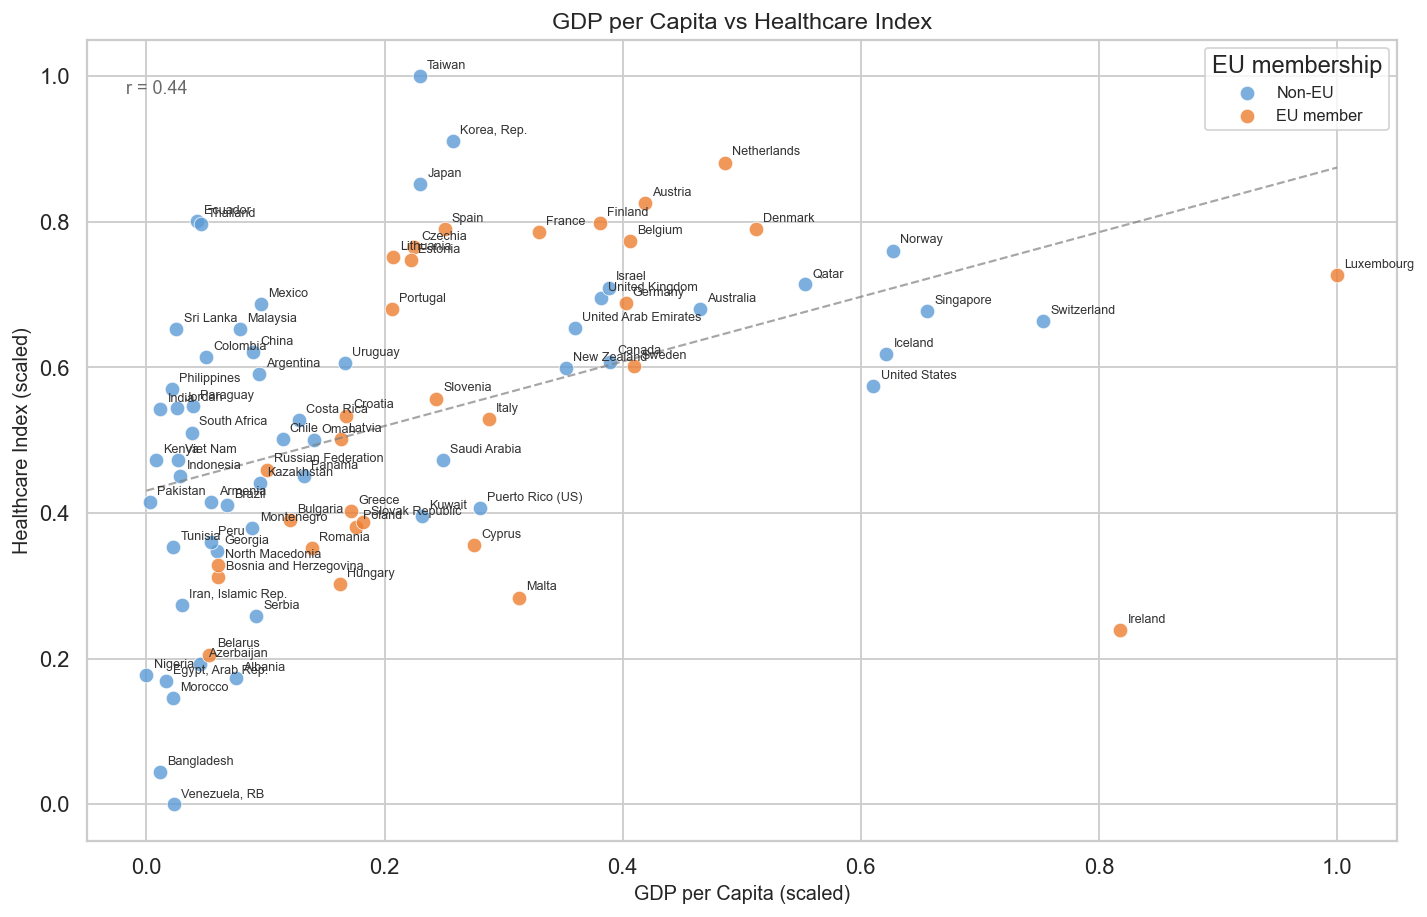

Saved → figures/04_gdp_vs_healthcare.png


In [8]:
X_COL = 'gdp_per_capita'
Y_COL = 'healthcare_index'
HUE   = 'eu_member'         # colour points by EU membership if available

missing = [c for c in (X_COL, Y_COL) if c not in df.columns]
if missing:
    print(f'Columns not found in dataset: {missing}. Skipping plot.')
else:
    plot_df = (
        df[[X_COL, Y_COL] + ([HUE] if HUE in df.columns else [])]
        .assign(label=labels)
        .dropna(subset=[X_COL, Y_COL])
    )

    fig, ax = plt.subplots(figsize=(13, 8))

    if HUE in plot_df.columns:
        palette = {0: '#5B9BD5', 1: '#ED7D31'}
        hue_labels = {0: 'Non-EU', 1: 'EU member'}
        for hue_val, grp in plot_df.groupby(HUE):
            ax.scatter(
                grp[X_COL], grp[Y_COL],
                s=65, alpha=0.80,
                color=palette[int(hue_val)],
                edgecolors='white', linewidths=0.5,
                label=hue_labels[int(hue_val)],
            )
        ax.legend(title='EU membership', fontsize=9)
    else:
        ax.scatter(plot_df[X_COL], plot_df[Y_COL], s=65, alpha=0.80,
                   color='mediumseagreen', edgecolors='white', linewidths=0.5)

    # Annotations
    for _, row in plot_df.iterrows():
        ax.annotate(
            row['label'],
            xy=(row[X_COL], row[Y_COL]),
            xytext=(4, 4), textcoords='offset points',
            fontsize=7, color='#333333',
        )

    # Trend line
    z = np.polyfit(plot_df[X_COL], plot_df[Y_COL], 1)
    p = np.poly1d(z)
    x_line = np.linspace(plot_df[X_COL].min(), plot_df[X_COL].max(), 200)
    ax.plot(x_line, p(x_line), color='grey', lw=1.2, ls='--', alpha=0.7, label='Trend')

    # Correlation annotation
    r = plot_df[[X_COL, Y_COL]].corr().iloc[0, 1]
    ax.text(0.03, 0.95, f'r = {r:.2f}', transform=ax.transAxes,
            fontsize=10, color='dimgrey', va='top')

    ax.set_xlabel('GDP per Capita (scaled)', fontsize=11)
    ax.set_ylabel('Healthcare Index (scaled)', fontsize=11)
    ax.set_title('GDP per Capita vs Healthcare Index', fontsize=13)

    fig.savefig(FIGURES_DIR / '04_gdp_vs_healthcare.png')
    plt.show()
    print('Saved → figures/04_gdp_vs_healthcare.png')